<a href="https://colab.research.google.com/github/saanvi-01/iiit-h_projects/blob/main/Copy_of_AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [ ]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # TODO: Calculate the linear output (w * x + b)
                # prediction = ...

                # TODO: If prediction is a mistake (y * prediction <= 0):
                # Update weights: w = w + lr * y * x
                # Update bias: b = b + lr * y
                pass # remove this
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# model_p = WaterPerceptron()
# model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [ ]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # TODO: 1. Compute linear output: z = Xw + b
            # TODO: 2. Calculate gradients:
            # dw = (1/n) * X.T.dot(z - y)
            # db = (1/n) * sum(z - y)

            # TODO: 3. Update w and b: w = w - lr * dw
            pass

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [ ]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # TODO: Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                if False: # Replace False with condition
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    # self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    # self.b -= self.lr * (-y[i])
                    pass

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  -

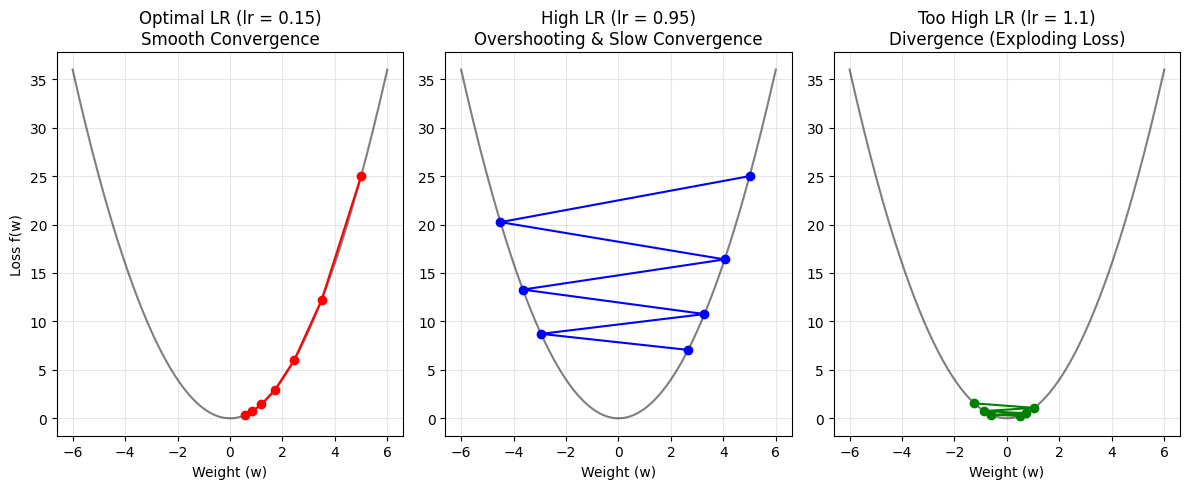

In [2]:
#Q1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())

# Simple Gradient Descent simulation on a toy 1D quadratic loss function / linear regression to illustrate learning rate impact clearly
# f(w) = w^2, f'(w) = 2*w

def run_gd(learning_rate, iterations=10, start_w=5.0):
    w_history = [start_w]
    w = start_w
    for _ in range(iterations):
        grad = 2 * w
        w = w - learning_rate * grad
        w_history.append(w)
        if abs(w) > 1e10:  # Divergence safeguard
            break
    return w_history

lrs = [0.1, 0.9, 1.0, 1.05]
for lr in lrs:
    history = run_gd(lr, 10, start_w=5.0)
    print(f"LR {lr}: {history[:6]}")

import numpy as np
import matplotlib.pyplot as plt

# Quadratic loss function f(w) = w^2
w_vals = np.linspace(-6, 6, 200)
loss_vals = w_vals**2

def simulate_gd(lr, steps=6, start_w=5.0):
    w_hist = [start_w]
    w = start_w
    for _ in range(steps):
        grad = 2 * w
        w = w - lr * grad
        w_hist.append(w)
    return np.array(w_hist)

# Test 3 regimes: Moderate (0.15), Oscillating (0.95), Divergent (1.1)
w_moderate = simulate_gd(0.15, steps=6, start_w=5.0)
w_oscillate = simulate_gd(0.95, steps=6, start_w=5.0)
w_divergent = simulate_gd(1.1, steps=5, start_w=0.5)

plt.figure(figsize=(12, 5))

# Plot 1: Moderate LR (Convergence)
plt.subplot(1, 3, 1)
plt.plot(w_vals, loss_vals, 'k-', alpha=0.5)
plt.plot(w_moderate, w_moderate**2, 'ro-', label='Path')
plt.title('Optimal LR (lr = 0.15)\nSmooth Convergence')
plt.xlabel('Weight (w)')
plt.ylabel('Loss f(w)')
plt.grid(True, alpha=0.3)

# Plot 2: Overshooting / Oscillation (LR close to upper bound)
plt.subplot(1, 3, 2)
plt.plot(w_vals, loss_vals, 'k-', alpha=0.5)
plt.plot(w_oscillate, w_oscillate**2, 'bo-', label='Path')
plt.title('High LR (lr = 0.95)\nOvershooting & Slow Convergence')
plt.xlabel('Weight (w)')
plt.grid(True, alpha=0.3)

# Plot 3: Too High LR (Divergence)
plt.subplot(1, 3, 3)
plt.plot(w_vals, loss_vals, 'k-', alpha=0.5)
plt.plot(w_divergent, w_divergent**2, 'go-', label='Path')
plt.title('Too High LR (lr = 1.1)\nDivergence (Exploding Loss)')
plt.xlabel('Weight (w)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_learning_rates.png')
plt.show()

In [3]:
#Q2
# Double checking formulas for Hinge loss with {-1, 1} vs {0, 1}
def hinge_loss_pm1(y, f_x):
    # y in {-1, 1}
    return max(0, 1 - y * f_x)

def hinge_loss_01(y, f_x):
    # y in {0, 1} - needs piecewise definition
    if y == 1:
        return max(0, 1 - f_x)
    else:
        return max(0, 1 + f_x)

# Verify equivalence for y=1 (corresponds to +1) and y=0 (corresponds to -1)
assert hinge_loss_pm1(1, 1.5) == hinge_loss_01(1, 1.5)
assert hinge_loss_pm1(-1, -1.5) == hinge_loss_01(0, -1.5)
print("Math check passed!")

Math check passed!


Soft-Margin SVM (RBF)  | Mean CV Accuracy: 0.6743 ± 0.0168
Logistic Regression    | Mean CV Accuracy: 0.6099 ± 0.0007
KNN (K=15)             | Mean CV Accuracy: 0.6459 ± 0.0080
Perceptron             | Mean CV Accuracy: 0.5232 ± 0.0556


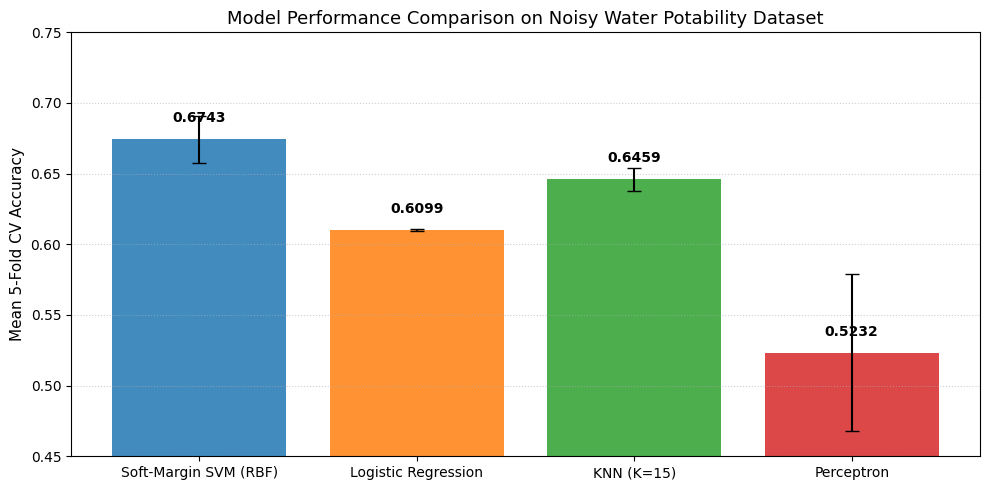

In [4]:
#Q3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Load Dataset
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

X = df.drop('Potability', axis=1)
y = df['Potability']

# 2. Preprocessing: Impute Missing Values & Scale Features
# Water potability dataset contains missing values in pH, Sulfate, and Trihalomethanes
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. Define Classifiers to Compare against Noisy/Non-Separable Data
models = {
    'Soft-Margin SVM (RBF)': SVC(C=1.0, kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, random_state=42),
    'KNN (K=15)': KNeighborsClassifier(n_neighbors=15),
    'Perceptron': Perceptron(max_iter=1000, random_state=42),
}

# 4. Evaluate using 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_mean = []
results_std = []
model_names = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    model_names.append(name)
    results_mean.append(scores.mean())
    results_std.append(scores.std())
    print(f'{name:22s} | Mean CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

# 5. Visualizing Model Performance on Noisy Data
plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = plt.bar(
    model_names,
    results_mean,
    yerr=results_std,
    capsize=5,
    color=colors,
    alpha=0.85,
)
plt.title(
    'Model Performance Comparison on Noisy Water Potability Dataset',
    fontsize=13,
)
plt.ylabel('Mean 5-Fold CV Accuracy', fontsize=11)
plt.ylim(0.45, 0.75)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Annotate accuracy values on top of bars
for bar, mean in zip(bars, results_mean):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean + 0.01,
        f'{mean:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold',
    )

plt.tight_layout()
plt.show()